In [5]:
## import dependencies
import os
import re
import sys
import h5py
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

## Add the path to the DiscEvolution directory
sys.path.append('/Users/ben/Downloads/Planet Formation/Code/DiscEvolution Core Accretion')

## import DiscEvolution modules
from DiscEvolution.constants import *
from DiscEvolution.grid import Grid
from DiscEvolution.star import SimpleStar
from DiscEvolution.eos import IrradiatedEOS, LocallyIsothermalEOS, SimpleDiscEOS
from DiscEvolution.disc import *
from DiscEvolution.viscous_evolution import ViscousEvolution, ViscousEvolutionFV, LBP_Solution, HybridWindModel, TaboneSolution
from DiscEvolution.disc import AccretionDisc
from DiscEvolution.dust import *
from DiscEvolution.dust import PlanetesimalFormation
from DiscEvolution.planet_formation import *
from DiscEvolution.diffusion import TracerDiffusion
from DiscEvolution.opacity import Tazzari2016
from DiscEvolution.chemistry import *

In [6]:
## Method to read data from an HDF5 dataset or group

def read_hdf5_array(obj):
    """
    Read data from either an HDF5 dataset or an HDF5 group.
    """

    ## Normal case (the data are stored as one HDF5 dataset)
    if isinstance(obj, h5py.Dataset):
        return np.array(obj)

    ## Ragged case (the data are stored as a group)
    elif isinstance(obj, h5py.Group):
        values = []

        for key in sorted(obj.keys(), key = int):
            values.append(np.array(obj[key]))

        return values

    ## Raise an error if an unexpected HDF5 object is encountered
    else:
        raise TypeError(f"Unexpected HDF5 object type: {type(obj)}")

## Method to load data from an HDF5 file

def load_data(filename, planets = True):
    """
    Load disc evolution output file (HDF5 only).

    Parameters:
        filename: Path to the HDF5 file.
        planets: Whether to load planet data.

    Returns:
        data: Dictionary containing the simulation output.
    """

    data = {}

    ## Extract the psi value from the filename
    match = re.search(r"psi([0-9.eE+-]+)", os.path.basename(filename))

    if match:
        psi = float(match.group(1))

    else:
        psi = None

    ## Open the HDF5 file in read-only mode
    with h5py.File(filename, "r") as f:

        ## ---------------- General simulation data ----------------

        general_keys = [
            "t",
            "disk_Mdot_star",
            "disk_Mass",
            "Tc",
            "Sigc"]

        for key in general_keys:
            ## Only load the quantity if it exists in the file
            if key in f:
                data[key] = np.array(f[key])


        ## ---------------- Alpha viscosity ----------------

        if "alpha_SS" in f:
            data["alpha_SS"] = float(f["alpha_SS"][()])

        elif "alpha_SS" in f.attrs:
            data["alpha_SS"] = float(f.attrs["alpha_SS"])

        else:
            data["alpha_SS"] = None

        if psi is not None:
            data["psi"] = psi

        ## ---------------- Disk profiles ----------------

        disk_keys = [
            "R",
            "Sigma_G",
            "Sigma_dust",
            "Sigma_pebbles",
            "Sigma_planetesimals",
            "Vdrift_grains",
            "Vdrift_pebbles",
            "St_grains",
            "St_pebbles",
            "St_planetesimals",
            "e_planetesimals",
            "i_planetesimals",
            "de2_dt",
            "di2_dt",
            "de2_dt_drag",
            "di2_dt_drag",
            "de2_dt_VS_embryo",
            "di2_dt_VS_embryo",
            "de2_dt_VS_pltsml",
            "di2_dt_VS_pltsml",
            "de2_dt_DF",
            "di2_dt_DF",
            "T"]

        for key in disk_keys:
            if key in f:
                data[key] = read_hdf5_array(f[key])

        ## ---------------- Planet data ----------------

        if planets:
            planet_keys = [
                "Mcs",
                "Mes",
                "Rp",
                "Mdot_planetesimal",
                "Mdot_pebble",
                "Mdot_migration",
                "Mdot_gas",
                "M_iso_planetesimal",
                "M_iso_pebble",
                "X_cores",
                "X_envs"]

            for key in planet_keys:
                if key in f:
                    data[key] = read_hdf5_array(f[key])

    return data

In [7]:
## Load eccentricity data

data_ode = load_data("/Users/ben/Downloads/Planet Formation/DiscEvolution Simulations/Output/20260731_1138_ode.h5", planets = True)
data_euler = load_data("/Users/ben/Downloads/Planet Formation/DiscEvolution Simulations/Output/20260731_1150_euler.h5", planets = True)
data_solve_ivp = load_data("/Users/ben/Downloads/Planet Formation/DiscEvolution Simulations/Output/20260731_1205_solve_ivp.h5", planets = True)

R = data_ode["R"]

e_ode = data_ode["e_planetesimals"]
e_euler = data_euler["e_planetesimals"]
e_solve_ivp = data_solve_ivp["e_planetesimals"]

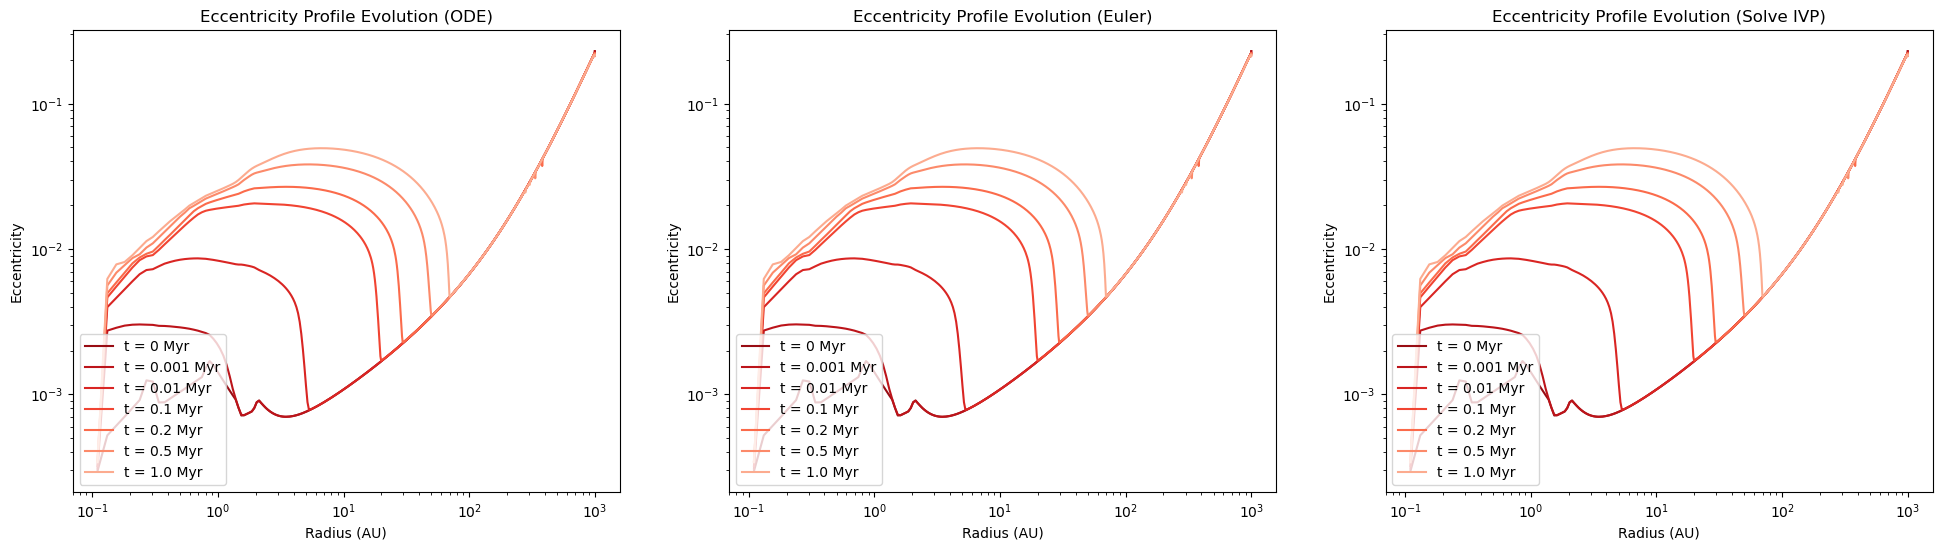

In [8]:
## Plot eccentricity profile evolution

fig, ax = plt.subplots(1, 3, figsize = (24, 6))

e_vals = [e_ode, e_euler, e_solve_ivp]
t_interval = [0, 0.001, 0.01, 0.1, 0.2, 0.5, 1.0]

colors = plt.cm.Reds(np.linspace(0.9, 0.3, len(t_interval)))

for i in range(len(e_vals)):
    for j in range(len(t_interval)):
        ax[i].plot(R[j], e_vals[i][j], color = colors[j], label = f't = {t_interval[j]} Myr')

    ax[i].set_xscale('log')
    ax[i].set_yscale('log')
    ax[i].legend(loc = 'lower left')
    ax[i].set_xlabel('Radius (AU)')
    ax[i].set_ylabel('Eccentricity')

ax[0].set_title('Eccentricity Profile Evolution (ODE)')
ax[1].set_title('Eccentricity Profile Evolution (Euler)')
ax[2].set_title('Eccentricity Profile Evolution (Solve IVP)')

plt.show()

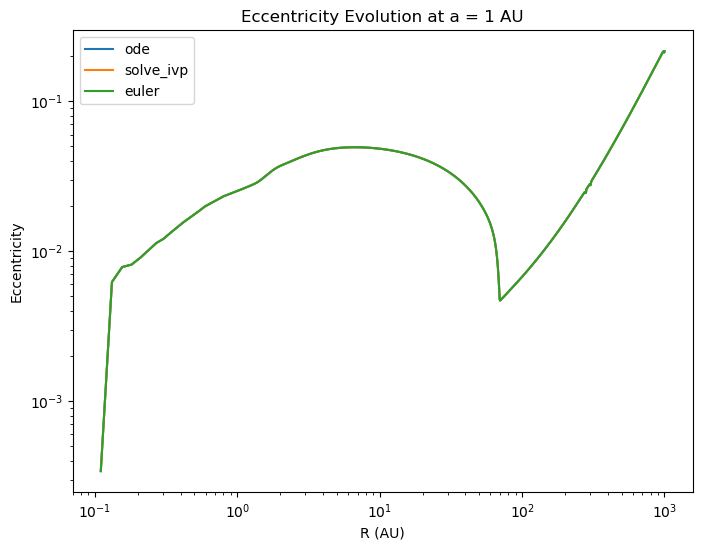

In [9]:
## Plot eccentricities

fig, ax = plt.subplots(figsize = (8, 6))

ax.plot(R[0], e_ode[-1], label = "ode")
ax.plot(R[0], e_solve_ivp[-1], label = "solve_ivp")
ax.plot(R[0], e_euler[-1], label = "euler")

plt.xscale('log')
plt.yscale('log')

plt.title('Eccentricity Evolution at a = 1 AU')
plt.xlabel('R (AU)')
plt.ylabel('Eccentricity')
plt.legend()
plt.show()

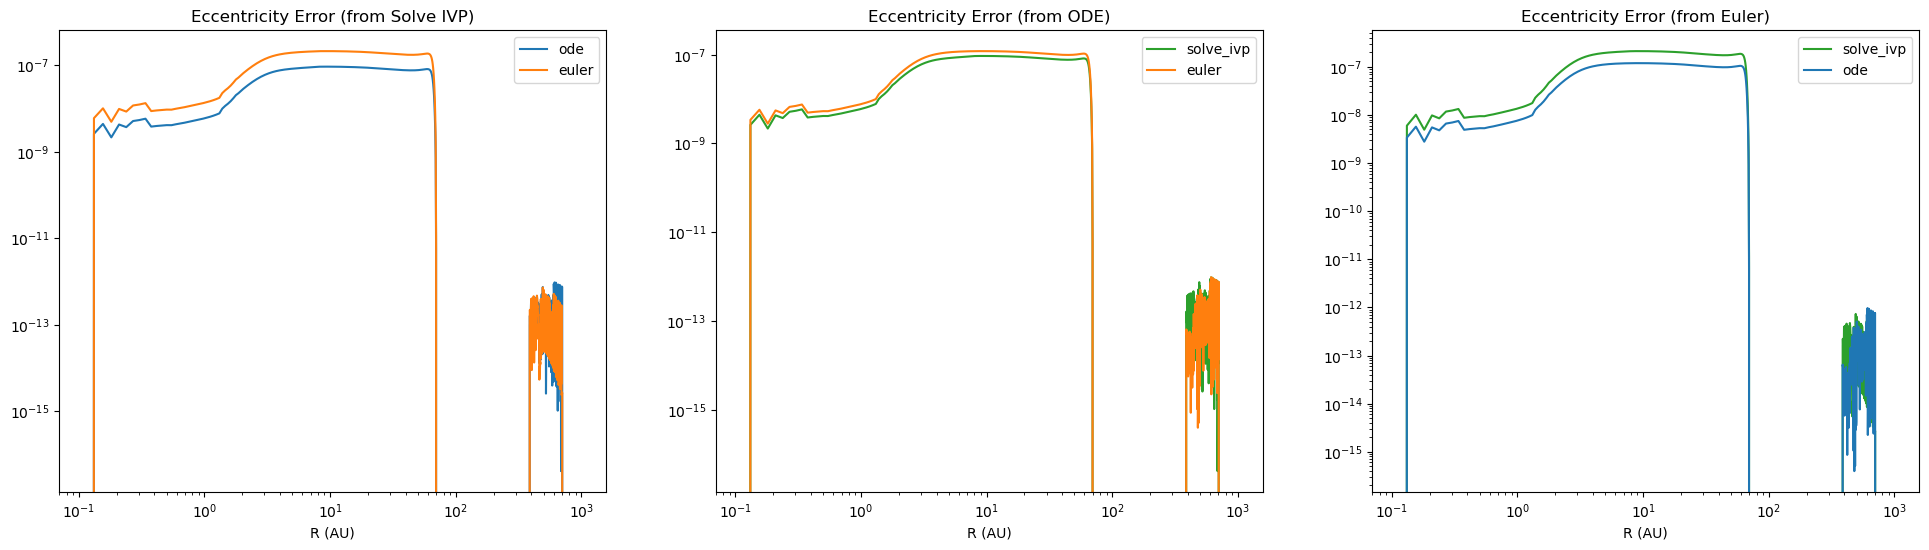

In [10]:
## Plot eccentricity error

fig, ax = plt.subplots(1, 3, figsize = (24, 6))

## Difference from solve_ivp

e_ivp_ode = np.abs(e_solve_ivp[-1] - e_ode[-1])
e_ivp_euler = np.abs(e_solve_ivp[-1] - e_euler[-1])

ax[0].plot(R[0], e_ivp_ode, color = 'tab:blue', label = "ode")
ax[0].plot(R[0], e_ivp_euler, color = 'tab:orange', label = "euler")

ax[0].set_xscale('log')
ax[0].set_yscale('log')
ax[0].set_title('Eccentricity Error (from Solve IVP)')
ax[0].set_xlabel('R (AU)')
ax[0].legend()

## Difference from ode

e_ode_ivp = np.abs(e_ode[-1] - e_solve_ivp[-1])
e_ode_euler = np.abs(e_ode[-1] - e_euler[-1])

ax[1].plot(R[0], e_ode_ivp, color = 'tab:green', label = "solve_ivp")
ax[1].plot(R[0], e_ode_euler, color = 'tab:orange', label = "euler")

ax[1].set_xscale('log')
ax[1].set_yscale('log')
ax[1].set_title('Eccentricity Error (from ODE)')
ax[1].set_xlabel('R (AU)')
ax[1].legend()

## Difference from euler

e_euler_ivp = np.abs(e_euler[-1] - e_solve_ivp[-1])
e_euler_ode = np.abs(e_euler[-1] - e_ode[-1])

ax[2].plot(R[0], e_euler_ivp, color = 'tab:green', label = "solve_ivp")
ax[2].plot(R[0], e_euler_ode, color = 'tab:blue', label = "ode")

ax[2].set_xscale('log')
ax[2].set_yscale('log')
ax[2].set_title('Eccentricity Error (from Euler)')
ax[2].set_xlabel('R (AU)')
ax[2].legend()

plt.show()